In [2]:
import numpy as _np
import matplotlib.pyplot as _plt

In [4]:
from scipy.stats import norm

def plotOnePhaseSpace(n_samples=5000, correl=0.9, theta=_np.pi/6, lim=[-5, 5], amp=5, alph_scatter=0.3, alph_gauss=0.5, lw=1):
    mean = _np.array([0, 0])
    cov = _np.array([[1, 0], [correl, 1]])

    z = _np.random.randn(n_samples, 2)

    L = _np.linalg.cholesky(cov)
    gaussian_samples = mean + z @ L.T

    R = _np.array([[_np.cos(theta), -_np.sin(theta)], 
                   [_np.sin(theta),  _np.cos(theta)]])

    rotated_samples = gaussian_samples @ R.T
    x, y = rotated_samples[:, 0], rotated_samples[:, 1]

    hist_x, bins_x = _np.histogram(x, bins=50, density=True)
    hist_y, bins_y = _np.histogram(y, bins=50, density=True)

    x_range = _np.linspace(min(x), max(x), 100)
    y_range = _np.linspace(min(y), max(y), 100)

    pdf_x = norm.pdf(x_range, _np.mean(x), _np.std(x))
    pdf_y = norm.pdf(y_range, _np.mean(y), _np.std(y))

    ax=_plt.gca()

    ax.plot(x_range, pdf_x * amp + lim[0], color="b", lw=lw, alpha=alph_gauss)
    ax.plot(pdf_y * amp + lim[0], y_range, color="r", lw=lw, alpha=alph_gauss)

    _plt.scatter(x, y, s=1.5, alpha=alph_scatter, color="k")
    _plt.ylim(lim[0], lim[1])
    _plt.xlim(lim[0], lim[1])
    
def plotAllPhaseSpace(n_samples=5000, 
                      correlx=0.9, thetax=_np.pi/6, 
                      correly=0.9, thetay=_np.pi/6, 
                      correlz=0.9, thetaz=_np.pi/6, 
                      lim=[-5, 5], amp=5, alph_scatter=0.3, alph_gauss=0.4, lw=1):
    _plt.rcParams['font.size'] = 17
    fig = _plt.figure(figsize=[13, 5])
    _plt.subplot(1, 3, 1)
    plotOnePhaseSpace(n_samples=n_samples, correl=correlx, theta=thetax, lim=lim, amp=amp, 
                      alph_scatter=alph_scatter, alph_gauss=alph_gauss, lw=lw)
    _plt.xlabel(r"$x$")
    _plt.ylabel(r"$x'$")
    _plt.legend([r"$\sigma_x$", r"$\sigma_{x'}$"])
    _plt.subplot(1, 3, 2)
    plotOnePhaseSpace(n_samples=n_samples, correl=correly, theta=thetay, lim=lim, amp=amp, 
                      alph_scatter=alph_scatter, alph_gauss=alph_gauss, lw=lw)
    _plt.xlabel(r"$y$")
    _plt.ylabel(r"$y'$")
    _plt.legend([r"$\sigma_y$", r"$\sigma_{y'}$"])
    _plt.subplot(1, 3, 3)
    plotOnePhaseSpace(n_samples=n_samples, correl=correlz, theta=thetaz, lim=lim, amp=amp, 
                      alph_scatter=alph_scatter, alph_gauss=alph_gauss, lw=lw)
    _plt.xlabel(r"$t$")
    _plt.ylabel(r"$E$")
    _plt.legend([r"$\sigma_t$", r"$\sigma_{E}$"])
    fig.tight_layout()

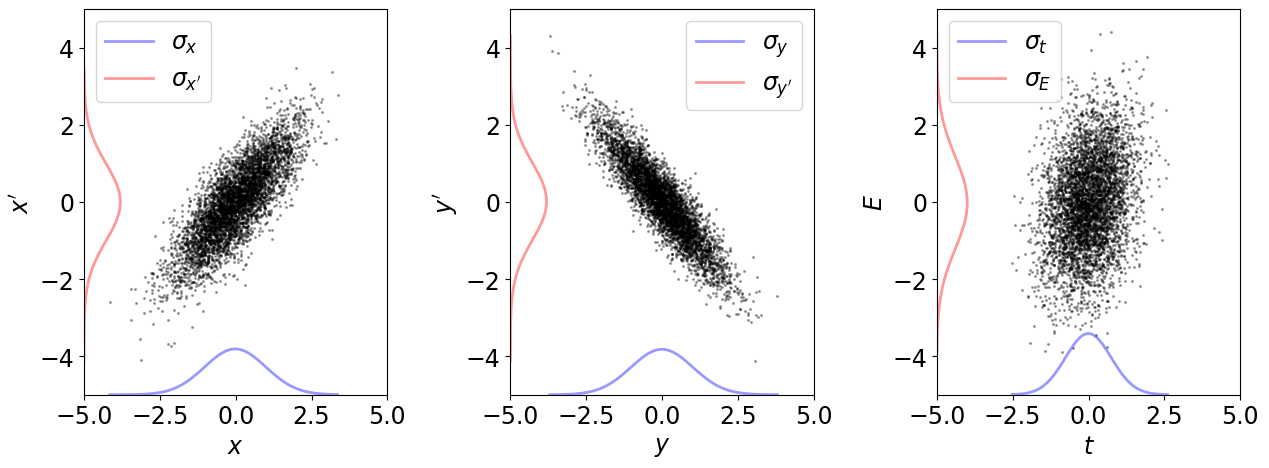

In [175]:
plotAllPhaseSpace(correlx=0.8, correly=0.9, correlz=0.5, thetax=0, thetay=_np.pi/2, amp=3, lw=2)

In [151]:
25e-15*3e8

7.5e-06

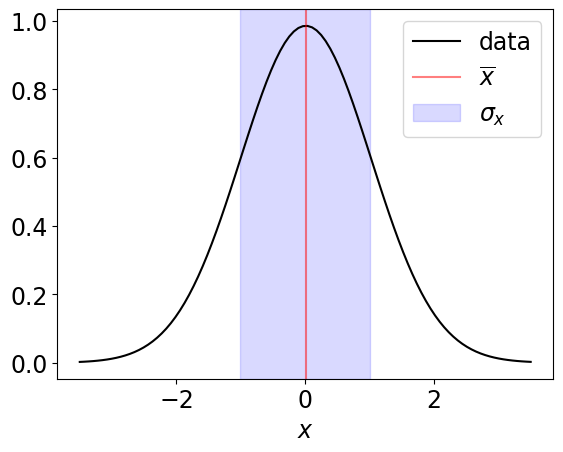

In [44]:
_plt.rcParams['font.size'] = 17
x = _np.random.randn(1000, 1)

x_range = _np.linspace(-3.5, +3.5, 100)

pdf_x = norm.pdf(x_range, _np.mean(x), _np.std(x))

_plt.xlabel("$x$")
_plt.plot(x_range, pdf_x*2.5, color='k', label="data")
_plt.axvline(_np.mean(x), color='r', label="$\overline{x}$", alpha=0.5)
_plt.axvspan(-_np.std(x), _np.std(x), color='b', alpha=0.15, label="$\sigma_x$")
_plt.legend()